# BERT

### 네이버 영화 리뷰 데이터 불러오기

In [2]:
!pip install Korpora

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 5.5 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
from Korpora import Korpora


corpus = Korpora.load("nsmc")
df = pd.DataFrame(corpus.test).sample(20000, random_state=42)


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : e9t@github
    Repository : https://github.com/e9t/nsmc
    References : www.lucypark.kr/docs/2015-pyconkr/#39

    Naver sentiment movie corpus v1.0
    This is a movie review dataset in the Korean language.
    Reviews were scraped from Naver Movies.

    The dataset construction is based on the method noted in
    [Large movie review dataset][^1] from Maas et al., 2011.

    [^1]: http://ai.stanford.edu/~amaas/data/sentiment/

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/

[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ratings_train.txt
[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ra

In [2]:
train, valid, test = np.split(
    df.sample(frac=1, random_state=42), [int(0.6 * len(df)), int(0.8 * len(df))]
)

print(train.head(5).to_markdown())
print(f"Training Data Size : {len(train)}")
print(f"Validation Data Size : {len(valid)}")
print(f"Testing Data Size : {len(test)}")

|       | text                                                     |   label |
|------:|:---------------------------------------------------------|--------:|
| 26891 | 역시 코믹액션은 성룡, 홍금보, 원표 삼인방이 최고지!!     |       1 |
| 25024 | 점수 후하게 줘야것네 별 반개~                            |       0 |
| 11666 | 오랜만에 느낄수 있는 [감독] 구타욕구.                    |       0 |
| 40303 | 본지는 좀 됬지만 극장서 돈주고 본게 아직까지 아까운 영화 |       0 |
| 18010 | 징키스칸이란 소재를 가지고 이것밖에 못만드냐             |       0 |
Training Data Size : 12000
Validation Data Size : 4000
Testing Data Size : 4000


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


### BERT 입력 텐서 생성

In [3]:
import torch
from transformers import BertTokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler


def make_dataset(data, tokenizer, device):
    tokenized = tokenizer(
        text=data.text.tolist(),
        padding="longest",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)
    labels = torch.tensor(data.label.values, dtype=torch.long).to(device)
    return TensorDataset(input_ids, attention_mask, labels)


def get_datalodader(dataset, sampler, batch_size):
    data_sampler = sampler(dataset)
    dataloader = DataLoader(dataset, sampler=data_sampler, batch_size=batch_size)
    return dataloader


epochs = 5
batch_size = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = BertTokenizer.from_pretrained(
    pretrained_model_name_or_path="bert-base-multilingual-cased",
    do_lower_case=False
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_datalodader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_datalodader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_datalodader(test_dataset, SequentialSampler, batch_size)

print(train_dataset[0])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(tensor([   101,  58466,   9812, 118956, 119122,  59095,  10892,   9434, 118888,
           117,   9992,  40032,  30005,    117,   9612,  37824,   9410,  12030,
         42337,  10739,  83491,  12508,    106,    106,    102,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,

1. **BERT 토크나이저 사용**
  * `bert-base-multilingual-cased`: 대소문자를 **유지**하며, **104개 언어**를 지원하는 사전 학습된 BERT 모델.
  * `do_lower_case=False`: `'Apple'`과 `'apple'`을 **서로 다른 단어**로 인식하도록 설정.

  > 다양한 언어의 자연어 처리 작업에 좋은 성능 기대 가능.

---

2. **토크나이저 → 텐서 데이터셋 변환**
  * `make_dataset` 함수에 토크나이저를 전달하여 **토큰화된 텐서 형식의 데이터셋**으로 변환.
  * `GPT` 예제 7.2 및 7.11과 동일한 방식.
  * 텍스트는 **ID(숫자 시퀀스)** 및 **attention mask**로 변환되고, 라벨도 텐서로 처리됨.

---

3. **데이터로더 적용**
  * `get_dataloader` 함수는 **샘플링 방식**에 따라 데이터를 로딩함.
  - 샘플러 종류:
    * `RandomSampler`: 데이터를 **무작위로 샘플링** (학습에 주로 사용)
    * `SequentialSampler`: 데이터를 **고정된 순서로 반환** (검증 및 평가에 사용)

---



### BERT 모델 선언

In [4]:
from torch import optim
from transformers import BertForSequenceClassification


model = BertForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="bert-base-multilingual-cased",
    num_labels=2
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps=1e-8)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

bert
└ embeddings
│  └ word_embeddings
│  └ position_embeddings
│  └ token_type_embeddings
│  └ LayerNorm
│  └ dropout
└ encoder
│  └ layer
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  │  └ 3
│  │  └ 4
│  │  └ 5
│  │  └ 6
│  │  └ 7
│  │  └ 8
│  │  └ 9
│  │  └ 10
│  │  └ 11
└ pooler
│  └ dense
│  └ activation
dropout
classifier


### BERT 모델 함수

In [7]:
import numpy as np
from torch import nn


def calc_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def train(model, optimizer, dataloader):
    model.train()
    train_loss = 0.0

    for input_ids, attention_mask, labels in dataloader:
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(dataloader)
    return train_loss

def evaluation(model, dataloader):
    with torch.no_grad():
        model.eval()
        criterion = nn.CrossEntropyLoss()
        val_loss, val_accuracy = 0.0, 0.0

        for input_ids, attention_mask, labels in dataloader:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            logits = outputs.logits

            loss = criterion(logits, labels)
            logits = logits.detach().cpu().numpy()
            label_ids = labels.to("cpu").numpy()
            accuracy = calc_accuracy(logits, label_ids)

            val_loss += loss.item()
            val_accuracy += accuracy

    val_loss = val_loss/len(dataloader)
    val_accuracy = val_accuracy/len(dataloader)
    return val_loss, val_accuracy


best_loss = 10000
for epoch in range(epochs):
    train_loss = train(model, optimizer, train_dataloader)
    val_loss, val_accuracy = evaluation(model, valid_dataloader)
    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Accuracy {val_accuracy:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "/content/models/BertForSequenceClassification.pt")
        print("Saved the model weights")

Epoch 1: Train Loss: 0.2755 Val Loss: 0.4469 Val Accuracy 0.8135
Saved the model weights
Epoch 2: Train Loss: 0.2052 Val Loss: 0.5329 Val Accuracy 0.8125
Epoch 3: Train Loss: 0.1670 Val Loss: 0.5341 Val Accuracy 0.8217
Epoch 4: Train Loss: 0.1309 Val Loss: 0.6033 Val Accuracy 0.8075
Epoch 5: Train Loss: 0.1096 Val Loss: 0.6776 Val Accuracy 0.8103


### BERT 모델 학습 결과

In [8]:
model = BertForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="bert-base-multilingual-cased",
    num_labels=2
).to(device)
model.load_state_dict(torch.load("/content/models/BertForSequenceClassification.pt"))

test_loss, test_accuracy = evaluation(model, test_dataloader)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Test Loss : 0.4385
Test Accuracy : 0.8123


# BART

### 허깅 페이스 모델 평가 라이브러리

In [10]:
!pip install evaluate rouge_score absl-py

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.1 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=ed84dff7e9884e24d13fe647916f3960176f7075eb7c36928224a03f8d659d98
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


### 뉴스 요약 데이터세트 불러오기

In [3]:
!pip install datasets==2.20.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 30.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.5.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [1]:
import numpy as np
from datasets import load_dataset

news = load_dataset("argilla/news-summary", split="test", cache_dir="/content/hf_cache")
df = news.to_pandas().sample(5000, random_state=42)[["text", "prediction"]]
df["prediction"] = df["prediction"].map(lambda x: x[0]["text"])
train, valid, test = np.split(
    df.sample(frac=1, random_state=42), [int(0.6 * len(df)), int(0.8 * len(df))]
)

print(f"Source News : {train.text.iloc[0][:200]}")
print(f"Summarization : {train.prediction.iloc[0][:50]}")
print(f"Training Data Size : {len(train)}")
print(f"Validation Data Size : {len(valid)}")
print(f"Testing Data Size : {len(test)}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20417 [00:00<?, ? examples/s]

Source News : DANANG, Vietnam (Reuters) - Russian President Vladimir Putin said on Saturday he had a normal dialogue with U.S. leader Donald Trump at a summit in Vietnam, and described Trump as civil, well-educated
Summarization : Putin says had useful interaction with Trump at Vi
Training Data Size : 3000
Validation Data Size : 1000
Testing Data Size : 1000


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


### BART 입력 텐서 생성

In [2]:
import torch
from transformers import BartTokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler
from torch.nn.utils.rnn import pad_sequence


def make_dataset(data, tokenizer, device):
    tokenized = tokenizer(
        text=data.text.tolist(),
        padding="longest",
        truncation=True,
        return_tensors="pt",
        max_length=1024
    )
    labels = []
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)
    for target in data.prediction:
        labels.append(tokenizer.encode(target, return_tensors="pt").squeeze())
    labels = pad_sequence(labels, batch_first=True, padding_value=-100).to(device)
    return TensorDataset(input_ids, attention_mask, labels)



def get_datalodader(dataset, sampler, batch_size):
    data_sampler = sampler(dataset)
    dataloader = DataLoader(dataset, sampler=data_sampler, batch_size=batch_size)
    return dataloader


epochs = 5
batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = BartTokenizer.from_pretrained(
    pretrained_model_name_or_path="facebook/bart-base"
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_datalodader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_datalodader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_datalodader(test_dataset, SequentialSampler, batch_size)

print(train_dataset[0])

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

(tensor([   0,  495, 1889,  ...,    1,    1,    1], device='cuda:0'), tensor([1, 1, 1,  ..., 0, 0, 0], device='cuda:0'), tensor([    0, 35891,   161,    56,  5616, 10405,    19,   140,    23,  5490,
         3564,     2,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0'))


### BART 모델 선언

In [3]:
from torch import optim
from transformers import BartForConditionalGeneration


model = BartForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path="facebook/bart-base"
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-5, eps=1e-8)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

**임베딩 계층 공유**
  * **`shared embedding`**: 인코더와 디코더가 **동일한 임베딩 계층**을 사용함.
    * 동일 단어에 대한 표현 학습이 통일되고, 모델 파라미터 수가 줄어드는 장점.
  * 마지막에는 `layernorm_embedding`을 통해 임베딩 벡터의 마지막 차원에 **정규화**를 적용하여 학습 안정화.

**인코더 & 디코더**
  * 인코더와 디코더 각각 **6개 층으로 구성**.
  * 인코더 마지막 계층의 출력은 디코더의 모든 계층 및 어텐션 연산의 입력으로 사용됨.
  * 디코더의 마지막 출력은 단어 사전의 크기만큼 Fully Connected Layer를 거쳐 **어휘 확률 분포**를 형성.

---
**BART 평가 지표: ROUGE(Recall-Oriented Understudy for Gisting Evaluation)**
  * **생성된 요약 문장**이 참조 요약 문장과 얼마나 유사한지 평가.
  * N-gram 기반 **정밀도**와 **재현율**을 활용.

---
  
**주요 ROUGE 지표**

| 지표           | 설명                                                |
| ------------ | ------------------------------------------------- |
| `ROUGE-N`    | N-gram 기반: 예) ROUGE-1 (unigram), ROUGE-2 (bigram) |
| `ROUGE-L`    | **LCS**(Longest Common Subsequence) 기반 평가         |
| `ROUGE-LSUM` | 개별 문장 간 LCS → 합집합(Union-LCS)으로 평가                 |
| `ROUGE-W`    | LCS에 **가중치** 부여하여 연속 LCS를 강조 (Weighted-LCS)       |

* **ROUGE-L**: 문장 전체에서 **최장 공통 부분 문자열**(LCS) 기반. 문장 구조를 고려.
* **ROUGE-LSUM**: 여러 문장을 각각 비교해 얻은 LCS들의 **합집합 길이** 기준 평가.
* **ROUGE-W**: 연속된 단어 유사도를 강조. 의미적 연결성이 높은 요약을 평가하는 데 유용.

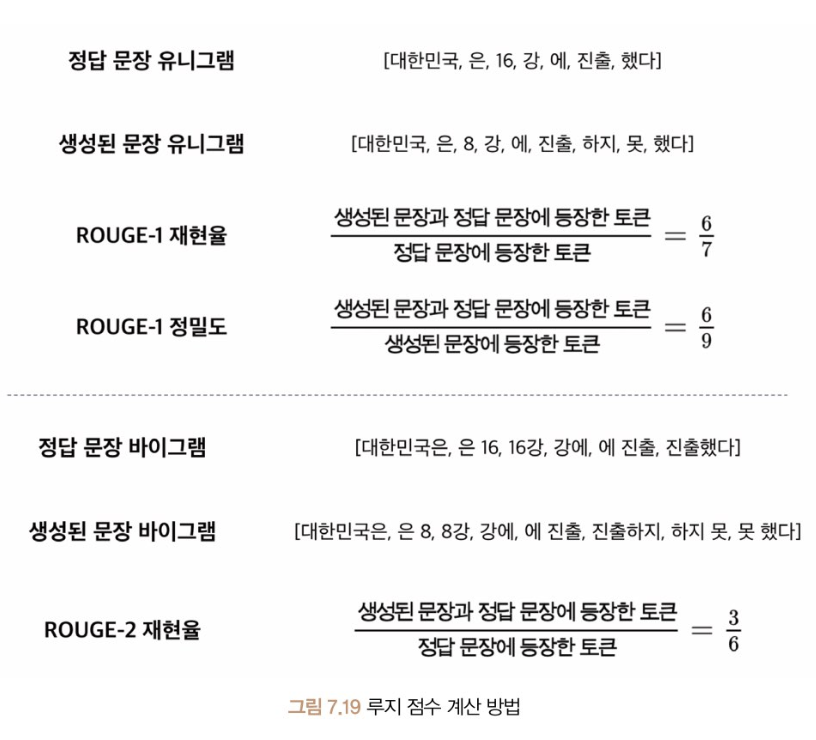

In [4]:
for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

model
└ shared
└ encoder
│  └ embed_tokens
│  └ embed_positions
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  │  └ 3
│  │  └ 4
│  │  └ 5
│  └ layernorm_embedding
└ decoder
│  └ embed_tokens
│  └ embed_positions
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  │  └ 3
│  │  └ 4
│  │  └ 5
│  └ layernorm_embedding
lm_head


### BART 모델 학습 및 평가

In [5]:
import numpy as np
import evaluate


def calc_rouge(preds, labels):
    preds = preds.argmax(axis=-1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    rouge2 = rouge_score.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )
    return rouge2["rouge2"]

def train(model, optimizer, dataloader):
    model.train()
    train_loss = 0.0

    for input_ids, attention_mask, labels in dataloader:
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(dataloader)
    return train_loss

def evaluation(model, dataloader):
    with torch.no_grad():
        model.eval()
        val_loss, val_rouge = 0.0, 0.0

        for input_ids, attention_mask, labels in dataloader:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            logits = outputs.logits
            loss = outputs.loss

            logits = logits.detach().cpu().numpy()
            label_ids = labels.to("cpu").numpy()
            rouge = calc_rouge(logits, label_ids)

            val_loss += loss.item()
            val_rouge += rouge

    val_loss = val_loss / len(dataloader)
    val_rouge = val_rouge / len(dataloader)
    return val_loss, val_rouge

rouge_score = evaluate.load("rouge", tokenizer=tokenizer)
best_loss = 10000
for epoch in range(epochs):
    train_loss = train(model, optimizer, train_dataloader)
    val_loss, val_accuracy = evaluation(model, valid_dataloader)
    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Rouge {val_accuracy:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "/content/models/BartForConditionalGeneration.pt")
        print("Saved the model weights")

Epoch 1: Train Loss: 2.1707 Val Loss: 1.8368 Val Rouge 0.2543
Saved the model weights
Epoch 2: Train Loss: 1.5967 Val Loss: 1.8990 Val Rouge 0.2573
Epoch 3: Train Loss: 1.3497 Val Loss: 1.9544 Val Rouge 0.2605
Epoch 4: Train Loss: 0.9697 Val Loss: 2.0485 Val Rouge 0.2560
Epoch 5: Train Loss: 0.7505 Val Loss: 2.1975 Val Rouge 0.2480


### BART 모델 평가

In [6]:
model = BartForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path="facebook/bart-base"
).to(device)
model.load_state_dict(torch.load("/content/models/BartForConditionalGeneration.pt"))

test_loss, test_rouge_score = evaluation(model, test_dataloader)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test ROUGE-2 Score : {test_rouge_score:.4f}")

Test Loss : 1.7930
Test ROUGE-2 Score : 0.2685


### 문장 요약문 비교

In [7]:
from transformers import pipeline


summarizer = pipeline(
    task="summarization",
    model=model,
    tokenizer=tokenizer,
    max_length=54,
    device="cpu"
)

for index in range(5):
    news_text = test.text.iloc[index]
    summarization = test.prediction.iloc[index]
    predicted_summarization = summarizer(news_text)[0]["summary_text"]
    print(f"정답 요약문 : {summarization}")
    print(f"모델 요약문 : {predicted_summarization}\n")

Device set to use cpu


정답 요약문 : Clinton leads Trump by 4 points in Washington Post: ABC News poll
모델 요약문 : Clinton leads Trump by 4 points: Washington Post-ABC News poll

정답 요약문 : Democrats question independence of Trump Supreme Court nominee
모델 요약문 : U.S. senators question Gorsuch's independence on Supreme Court

정답 요약문 : In push for Yemen aid, U.S. warned Saudis of threats in Congress
모델 요약문 : U.S. warns Saudi Arabia over Yemen humanitarian situation

정답 요약문 : Romanian ruling party leader investigated over 'criminal group'
모델 요약문 : Romania's Dragnea faces charges of fraud, corruption

정답 요약문 : Billionaire environmental activist Tom Steyer endorses Clinton
모델 요약문 : Environmental activist Steyer backs Clinton for U.S. president



# ELECTRA

### 네이버 영화 리뷰 데이터세트 전처리

In [8]:
import numpy as np
import pandas as pd
from Korpora import Korpora


corpus = Korpora.load("nsmc")
df = pd.DataFrame(corpus.test).sample(20000, random_state=42)
train, valid, test = np.split(
    df.sample(frac=1, random_state=42), [int(0.6 * len(df)), int(0.8 * len(df))]
)

print(train.head(5).to_markdown())
print(f"Training Data Size : {len(train)}")
print(f"Validation Data Size : {len(valid)}")
print(f"Testing Data Size : {len(test)}")


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : e9t@github
    Repository : https://github.com/e9t/nsmc
    References : www.lucypark.kr/docs/2015-pyconkr/#39

    Naver sentiment movie corpus v1.0
    This is a movie review dataset in the Korean language.
    Reviews were scraped from Naver Movies.

    The dataset construction is based on the method noted in
    [Large movie review dataset][^1] from Maas et al., 2011.

    [^1]: http://ai.stanford.edu/~amaas/data/sentiment/

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/

[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ratings_train.txt
[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ra

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


### KoELECTRA 모델 선언

In [9]:
import torch
from transformers import ElectraTokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler


def make_dataset(data, tokenizer, device):
    tokenized = tokenizer(
        text=data.text.tolist(),
        padding="longest",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)
    labels = torch.tensor(data.label.values, dtype=torch.long).to(device)
    return TensorDataset(input_ids, attention_mask, labels)


def get_datalodader(dataset, sampler, batch_size):
    data_sampler = sampler(dataset)
    dataloader = DataLoader(dataset, sampler=data_sampler, batch_size=batch_size)
    return dataloader


epochs = 5
batch_size = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = ElectraTokenizer.from_pretrained(
    pretrained_model_name_or_path="monologg/koelectra-base-v3-discriminator",
    do_lower_case=False,
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_datalodader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_datalodader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_datalodader(test_dataset, SequentialSampler, batch_size)

print(train_dataset[0])

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/263k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

(tensor([    2,  6511, 14347,  4087,  4665,  4112,  2924,  4806,    16,  3809,
         4309,  4275,    16,  3201,  4376,  2891,  4139,  4212,  4007,  6557,
         4200,     5,     5,     3,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0], device='cuda:0'), tensor([1, 1, 1, 1, 1, 1, 1, 

In [10]:
from torch import optim
from transformers import ElectraForSequenceClassification


model = ElectraForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="monologg/koelectra-base-v3-discriminator",
    num_labels=2
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps=1e-8)

pytorch_model.bin:   0%|          | 0.00/452M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at monologg/koelectra-base-v3-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

electra
└ embeddings
│  └ word_embeddings
│  └ position_embeddings
│  └ token_type_embeddings
│  └ LayerNorm
│  └ dropout
└ encoder
│  └ layer
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  │  └ 3
│  │  └ 4
│  │  └ 5
│  │  └ 6
│  │  └ 7
│  │  └ 8
│  │  └ 9
│  │  └ 10
│  │  └ 11
classifier
└ dense
└ activation
└ dropout
└ out_proj


In [12]:
import numpy as np
from torch import nn


def calc_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def train(model, optimizer, dataloader):
    model.train()
    train_loss = 0.0

    for input_ids, attention_mask, labels in dataloader:
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(dataloader)
    return train_loss

def evaluation(model, dataloader):
    with torch.no_grad():
        model.eval()
        criterion = nn.CrossEntropyLoss()
        val_loss, val_accuracy = 0.0, 0.0

        for input_ids, attention_mask, labels in dataloader:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            logits = outputs.logits

            loss = criterion(logits, labels)
            logits = logits.detach().cpu().numpy()
            label_ids = labels.to("cpu").numpy()
            accuracy = calc_accuracy(logits, label_ids)

            val_loss += loss.item()
            val_accuracy += accuracy

    val_loss = val_loss/len(dataloader)
    val_accuracy = val_accuracy/len(dataloader)
    return val_loss, val_accuracy


best_loss = 10000
for epoch in range(epochs):
    train_loss = train(model, optimizer, train_dataloader)
    val_loss, val_accuracy = evaluation(model, valid_dataloader)
    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Accuracy {val_accuracy:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "/content/models/ElectraForSequenceClassification.pt")
        print("Saved the model weights")

Epoch 1: Train Loss: 0.4645 Val Loss: 0.3563 Val Accuracy 0.8518
Saved the model weights
Epoch 2: Train Loss: 0.2946 Val Loss: 0.3097 Val Accuracy 0.8740
Saved the model weights
Epoch 3: Train Loss: 0.3194 Val Loss: 0.3321 Val Accuracy 0.8655
Epoch 4: Train Loss: 0.2671 Val Loss: 0.3468 Val Accuracy 0.8665
Epoch 5: Train Loss: 0.2162 Val Loss: 0.3286 Val Accuracy 0.8745


### KoELECTRA 모델 평가 결과

In [13]:
model = ElectraForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="monologg/koelectra-base-v3-discriminator",
    num_labels=2
).to(device)
model.load_state_dict(torch.load("/content/models/ElectraForSequenceClassification.pt"))

test_loss, test_accuracy = evaluation(model, test_dataloader)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at monologg/koelectra-base-v3-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Test Loss : 0.3214
Test Accuracy : 0.8698


# T5

### 뉴스 요약 데이터세트 불러오기

In [14]:
import numpy as np
from datasets import load_dataset


news = load_dataset("argilla/news-summary", split="test")
df = news.to_pandas().sample(5000, random_state=42)[["text", "prediction"]]
df["text"] = "summarize: " + df["text"]
df["prediction"] = df["prediction"].map(lambda x: x[0]["text"])
train, valid, test = np.split(
    df.sample(frac=1, random_state=42), [int(0.6 * len(df)), int(0.8 * len(df))]
)

print(f"Source News : {train.text.iloc[0][:200]}")
print(f"Summarization : {train.prediction.iloc[0][:50]}")
print(f"Training Data Size : {len(train)}")
print(f"Validation Data Size : {len(valid)}")
print(f"Testing Data Size : {len(test)}")

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20417 [00:00<?, ? examples/s]

Source News : summarize: DANANG, Vietnam (Reuters) - Russian President Vladimir Putin said on Saturday he had a normal dialogue with U.S. leader Donald Trump at a summit in Vietnam, and described Trump as civil, we
Summarization : Putin says had useful interaction with Trump at Vi
Training Data Size : 3000
Validation Data Size : 1000
Testing Data Size : 1000


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


### 뉴스 요약 데이터세트 전처리

In [15]:
import torch
from transformers import T5Tokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler
from torch.nn.utils.rnn import pad_sequence


def make_dataset(data, tokenizer, device):
    source = tokenizer(
        text=data.text.tolist(),
        padding="max_length",
        max_length=128,
        pad_to_max_length=True,
        truncation=True,
        return_tensors="pt"
    )

    target = tokenizer(
        text=data.prediction.tolist(),
        padding="max_length",
        max_length=128,
        pad_to_max_length=True,
        truncation=True,
        return_tensors="pt"
    )

    source_ids = source["input_ids"].squeeze().to(device)
    source_mask = source["attention_mask"].squeeze().to(device)
    target_ids = target["input_ids"].squeeze().to(device)
    target_mask = target["attention_mask"].squeeze().to(device)
    return TensorDataset(source_ids, source_mask, target_ids, target_mask)

def get_datalodader(dataset, sampler, batch_size):
    data_sampler = sampler(dataset)
    dataloader = DataLoader(dataset, sampler=data_sampler, batch_size=batch_size)
    return dataloader


epochs = 5
batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = T5Tokenizer.from_pretrained(
    pretrained_model_name_or_path="t5-small"
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_datalodader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_datalodader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_datalodader(test_dataset, SequentialSampler, batch_size)

print(next(iter(train_dataloader)))
print(tokenizer.convert_ids_to_tokens(21603))
print(tokenizer.convert_ids_to_tokens(10))

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


[tensor([[21603,    10,   549,  ...,   113,     3,     1],
        [21603,    10,  4083,  ...,    11, 18915,     1],
        [21603,    10,  4935,  ...,     7,   608,     1],
        ...,
        [21603,    10,   549,  ...,  2066,    92,     1],
        [21603,    10,     3,  ...,    32,  7542,     1],
        [21603,    10,   272,  ...,   955,  3478,     1]], device='cuda:0'), tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), tensor([[ 1531,    13,   412,  ...,     0,     0,     0],
        [14298,   343,     7,  ...,     0,     0,     0],
        [    3, 29759, 13980,  ...,     0,     0,     0],
        ...,
        [  621, 13050, 13423,  ...,     0,     0,     0],
        [15428,  9177,     7,  ...,     0,     0,     0],
        [22768,    31,     7,  ...,     0,     0,     0]], device='cuda:0'), ten

### T5 모델 선언

In [16]:
from torch import optim
from transformers import T5ForConditionalGeneration


model = T5ForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path="t5-small",
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps=1e-8)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

### T5 모델 학습 및 평가

In [17]:
import numpy as np
from torch import nn


def calc_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)


def train(model, optimizer, dataloader):
    model.train()
    train_loss = 0.0

    for source_ids, source_mask, target_ids, target_mask in dataloader:
        decoder_input_ids = target_ids[:, :-1].contiguous()
        labels = target_ids[:, 1:].clone().detach()
        labels[target_ids[:, 1:] == tokenizer.pad_token_id] = -100

        outputs = model(
            input_ids=source_ids,
            attention_mask=source_mask,
            decoder_input_ids=decoder_input_ids,
            labels=labels,
        )

        loss = outputs.loss
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(dataloader)
    return train_loss


def evaluation(model, dataloader):
    with torch.no_grad():
        model.eval()
        val_loss = 0.0

        for source_ids, source_mask, target_ids, target_mask in dataloader:
            decoder_input_ids = target_ids[:, :-1].contiguous()
            labels = target_ids[:, 1:].clone().detach()
            labels[target_ids[:, 1:] == tokenizer.pad_token_id] = -100

            outputs = model(
                input_ids=source_ids,
                attention_mask=source_mask,
                decoder_input_ids=decoder_input_ids,
                labels=labels,
            )

            loss = outputs.loss
            val_loss += loss.item()

    val_loss = val_loss / len(dataloader)
    return val_loss


best_loss = 10000
for epoch in range(epochs):
    train_loss = train(model, optimizer, train_dataloader)
    val_loss = evaluation(model, valid_dataloader)
    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "/content/models/T5ForConditionalGeneration.pt")
        print("Saved the model weights")

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch 1: Train Loss: 4.3060 Val Loss: 3.3076
Saved the model weights
Epoch 2: Train Loss: 3.4163 Val Loss: 2.9134
Saved the model weights
Epoch 3: Train Loss: 3.1438 Val Loss: 2.7626
Saved the model weights
Epoch 4: Train Loss: 2.9926 Val Loss: 2.6729
Saved the model weights
Epoch 5: Train Loss: 2.8904 Val Loss: 2.6118
Saved the model weights


### T5 생성 모델 테스트

In [18]:
model.eval()
with torch.no_grad():
    for source_ids, source_mask, target_ids, target_mask in test_dataloader:
        generated_ids = model.generate(
            input_ids=source_ids,
            attention_mask=source_mask,
            max_length=128,
            num_beams=3,
            repetition_penalty=2.5,
            length_penalty=1.0,
            early_stopping=True,
        )

        for generated, target in zip(generated_ids, target_ids):
            pred = tokenizer.decode(
                generated, skip_special_tokens=True, clean_up_tokenization_spaces=True
            )
            actual = tokenizer.decode(
                target, skip_special_tokens=True, clean_up_tokenization_spaces=True
            )
            print("Generated Headline Text:", pred)
            print("Actual Headline Text   :", actual)
        break

Generated Headline Text: Clinton leads Trump by 4 percentage points in four-war race for Nov. 8 election
Actual Headline Text   : Clinton leads Trump by 4 points in Washington Post: ABC News poll
Generated Headline Text: U.S. senators sharpen line of attack against Gorsuch's nomination to Supreme Court
Actual Headline Text   : Democrats question independence of Trump Supreme Court nominee
Generated Headline Text: U.S. warns Saudi Arabia over humanitarian situation in Yemen could constrain U.S. aid.
Actual Headline Text   : In push for Yemen aid, U.S. warned Saudis of threats in Congress
Generated Headline Text: Romanian anti-corruption prosecutors open investigation into Liviu Dragnea on suspicion of forming criminal group to siphon off cash from state projects
Actual Headline Text   : Romanian ruling party leader investigated over 'criminal group'
Generated Headline Text: environmental activist endorses Clinton for U.S. president a day after she secured Democratic nomination to run in